In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm

In [2]:
# client = scaleout.make_dask_client("tls://localhost:8786")
# client

In [3]:
nfiles = 1

channels = ["baseNoLjNoLjsource_noTrigger", "baseNoLjNoLjsource", "baseNoLj", "gen_allevt", "gen_leptons_final",] #sel.yaml

ch1 = channels[0] # gen cuts, and pv filter
ch2 = channels[1] # apply trigger, gen cuts, and pv filter
ch3 = channels[2] # ljsources
ch4 = channels[3] # my selections
ch5 = channels[4]

cha = [ch1, ch2, ch3, ch4, ch5]

In [4]:
#processor

runner = processor.Runner(
    executor=processor.FuturesExecutor(),           # local
    # executor=processor.IterativeExecutor(),
    # executor=processor.DaskExecutor(client=client),   # dask
    # schema=NanoAODSchema,
    schema = llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)
p = sidm_processor.SidmProcessor(
    channels,
    ["gen_base"],
)

In [5]:
sig_2mu = [
#     "2Mu2E_200GeV_5p0GeV_200p0mm",
#     "2Mu2E_500GeV_5p0GeV_80p0mm",
#     "2Mu2E_800GeV_5p0GeV_50p0mm",
#     "2Mu2E_1000GeV_5p0GeV_40p0mm",
    
#     "2Mu2E_500GeV_0p25GeV_4p0mm",
    "2Mu2E_500GeV_1p2GeV_19p0mm",
    # "2Mu2E_500GeV_5p0GeV_80p0mm",

#     "2Mu2E_500GeV_5p0GeV_0p08mm",
#     "2Mu2E_500GeV_5p0GeV_0p8mm",
#     "2Mu2E_500GeV_5p0GeV_8p0mm",
#     "2Mu2E_500GeV_5p0GeV_40p0mm",
#     "2Mu2E_500GeV_5p0GeV_80p0mm",
]

sig_4mu = [
#     "4Mu_200GeV_5p0GeV_200p0mm",
#     "4Mu_500GeV_5p0GeV_80p0mm",
#     "4Mu_800GeV_5p0GeV_50p0mm",
#     "4Mu_1000GeV_5p0GeV_40p0mm",

#     "4Mu_500GeV_0p25GeV_4p0mm",
    "4Mu_500GeV_1p2GeV_19p0mm",
#     "4Mu_500GeV_5p0GeV_80p0mm",

#     "4Mu_500GeV_5p0GeV_0p08mm",
#     "4Mu_500GeV_5p0GeV_0p8mm",
#     "4Mu_500GeV_5p0GeV_8p0mm",
#     "4Mu_500GeV_5p0GeV_40p0mm",
#     "4Mu_500GeV_5p0GeV_80p0mm",
]

In [6]:
# process 2mu
fileset_2mu = utilities.make_fileset(sig_2mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_2mu2e_v10.yaml")
out_2mu = runner.run(fileset_2mu, treename="Events", processor_instance=p)
out_2mu["out"]
# out_2mu
coffea.util.save(out_2mu, "outputs/master_2mu_gen.coffea")
# out_2mu

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


2Mu2E_500GeV_1p2GeV_19p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [7]:
#process 4mu
# fileset_4mu = utilities.make_fileset(sig_4mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_4mu_v10.yaml")
# out_4mu = runner.run(fileset_4mu, treename="Events", processor_instance=p)
# out_4mu = out_4mu["out"]
# coffea.util.save(out_4mu, "outputs/master_4mu_gen.coffea")

In [8]:
out_all = out_2mu# | out_4mu
coffea.util.save(out_all, "outputs/master_gen.coffea")

In [9]:
out_2mu

{'out': {'2Mu2E_500GeV_1p2GeV_19p0mm': {'cutflow': {'baseNoLjNoLjsource_noTrigger': <sidm.tools.cutflow.SimpleCutflow at 0x7fac4e467980>,
    'baseNoLjNoLjsource': <sidm.tools.cutflow.SimpleCutflow at 0x7fac4e467bf0>,
    'baseNoLj': <sidm.tools.cutflow.SimpleCutflow at 0x7fac4e464ce0>,
    'gen_allevt': <sidm.tools.cutflow.SimpleCutflow at 0x7fac4e4643e0>,
    'gen_leptons_final': <sidm.tools.cutflow.SimpleCutflow at 0x7fac4f924e90>},
   'hists': {'genE_n': Hist(
      StrCategory(['baseNoLjNoLjsource_noTrigger', 'baseNoLjNoLjsource', 'baseNoLj', 'gen_allevt', 'gen_leptons_final'], name='channel'),
      Regular(10, 0, 10, name='genEs_n', label='Number of genEss'),
      storage=Weight()) # Sum: WeightedSum(value=196.856, variance=3.90255) (WeightedSum(value=203.596, variance=4.03618) with flow),
    'genE_pt': Hist(
      StrCategory(['baseNoLjNoLjsource_noTrigger', 'baseNoLjNoLjsource', 'baseNoLj', 'gen_allevt', 'gen_leptons_final'], name='channel'),
      Regular(100, 0, 500, name=

In [10]:
out_all

{'out': {'2Mu2E_500GeV_1p2GeV_19p0mm': {'cutflow': {'baseNoLjNoLjsource_noTrigger': <sidm.tools.cutflow.SimpleCutflow at 0x7fac4e467980>,
    'baseNoLjNoLjsource': <sidm.tools.cutflow.SimpleCutflow at 0x7fac4e467bf0>,
    'baseNoLj': <sidm.tools.cutflow.SimpleCutflow at 0x7fac4e464ce0>,
    'gen_allevt': <sidm.tools.cutflow.SimpleCutflow at 0x7fac4e4643e0>,
    'gen_leptons_final': <sidm.tools.cutflow.SimpleCutflow at 0x7fac4f924e90>},
   'hists': {'genE_n': Hist(
      StrCategory(['baseNoLjNoLjsource_noTrigger', 'baseNoLjNoLjsource', 'baseNoLj', 'gen_allevt', 'gen_leptons_final'], name='channel'),
      Regular(10, 0, 10, name='genEs_n', label='Number of genEss'),
      storage=Weight()) # Sum: WeightedSum(value=196.856, variance=3.90255) (WeightedSum(value=203.596, variance=4.03618) with flow),
    'genE_pt': Hist(
      StrCategory(['baseNoLjNoLjsource_noTrigger', 'baseNoLjNoLjsource', 'baseNoLj', 'gen_allevt', 'gen_leptons_final'], name='channel'),
      Regular(100, 0, 500, name=

['2Mu2E_500GeV_1p2GeV_19p0mm']
2Mu2E_500GeV_1p2GeV_19p0mm


KeyError: '2Mu2E_500GeV_1p2GeV_19p0mm'

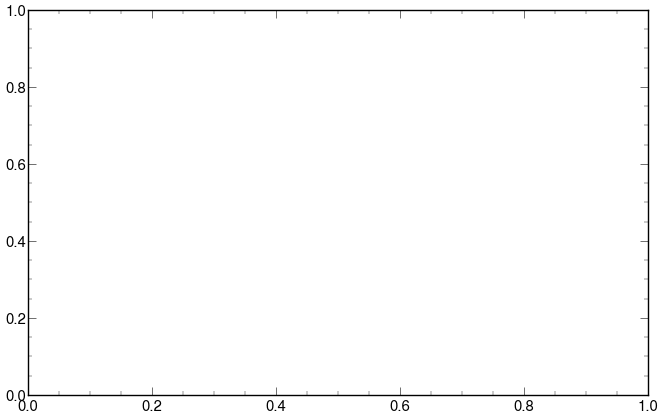

In [11]:
npl = 2
hToplot = ["genE_n", "genE_pt"]
title = ["Number of gen Eletrons", "gen Electron Pt",]
out = coffea.util.load("outputs/master_gen.coffea")
out2 = coffea.util.load("outputs/master_2mu_gen.coffea")

print(sig_2mu)
for tlt, hts in enumerate(hToplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for sss in sig_2mu:
        print(sss)
        utilities.plot(out2[sss]["hists"][hts][ch3, :], label = sss, density=False)
    plt.title(title[tlt])
    plt.legend(alignment="left", loc=0)
    plt.ylabel("Arbitrary units")
    plt.savefig(f"gen_plots/ch5_{hts}", bbox_inches="tight")